## Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df=pd.read_excel('D:\Job Stimulation\Tata Job Simulation ( Gen Ai Powered)\Delinquency_prediction_dataset.xlsx')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

#### Key Takeaways: Data Overview

Dataset Scale: 500 total rows across 9 primary numeric features and 6 historical tracking features (Month_1 to Month_6).

Target Feature: Delinquent_Account is a binary integer (0 or 1) with a 16% positive class base rate (80 delinquent accounts vs. 420 current accounts).

Feature Types: Features consist of numeric demographics (Age), financial capacity metrics (Income, Debt_to_Income_Ratio, Loan_Balance), risk scores (Credit_Score), and historical behavioral features (Month strings, Missed_Payments).

#### Missing Value Analysis

In [10]:
print(df.isnull().mean()*100)
df.describe()

Customer_ID             0.0
Age                     0.0
Income                  7.8
Credit_Score            0.4
Credit_Utilization      0.0
Missed_Payments         0.0
Delinquent_Account      0.0
Loan_Balance            5.8
Debt_to_Income_Ratio    0.0
Employment_Status       0.0
Account_Tenure          0.0
Credit_Card_Type        0.0
Location                0.0
Month_1                 0.0
Month_2                 0.0
Month_3                 0.0
Month_4                 0.0
Month_5                 0.0
Month_6                 0.0
dtype: float64


,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
count,500.000000,461.000000,498.000000,500.000000,500.000000,500.000000,471.000000,500.000000,500.000000
mean,46.266000,108379.893709,577.716867,0.491446,2.968000,0.160000,48654.428875,0.298862,9.740000
std,16.187629,53662.723741,168.881211,0.197103,1.946935,0.366973,29395.537273,0.094521,5.923054
min,18.000000,15404.000000,301.000000,0.050000,0.000000,0.000000,612.000000,0.100000,0.000000
25%,33.000000,62295.000000,418.250000,0.356486,1.000000,0.000000,23716.500000,0.233639,5.000000
50%,46.500000,107658.000000,586.000000,0.485636,3.000000,0.000000,45776.000000,0.301634,10.000000
75%,59.250000,155734.000000,727.250000,0.634440,5.000000,0.000000,75546.500000,0.362737,15.000000
max,74.000000,199943.000000,847.000000,1.025843,6.000000,1.000000,99620.000000,0.552956,19.000000


#### Key Takeaways: Missing Value Analysis

Income (7.8% Missing / 39 Rows): Represents the highest data gap. Requires conditional imputation (e.g., median value mapped to Employment_Status) to avoid flattening downstream model variance.

Loan_Balance (5.8% Missing / 29 Rows): Moderate missingness. Should be filled using median imputation or predicted via a proxy model using card type and credit limits.

Credit_Score (0.4% Missing / 2 Rows): Negligible missingness. Safe to resolve using a simple global median imputation.

Note: All other core features (Age, Credit_Utilization, Missed_Payments, Debt_to_Income_Ratio, Account_Tenure) are 100% complete.


#### Correlation with delinquency

In [12]:
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()
print(corr_matrix)

                           Age    Income  Credit_Score  Credit_Utilization  \
Age                   1.000000  0.006496     -0.034075            0.015811   
Income                0.006496  1.000000      0.071287            0.041181   
Credit_Score         -0.034075  0.071287      1.000000           -0.021550   
Credit_Utilization    0.015811  0.041181     -0.021550            1.000000   
Missed_Payments      -0.023511 -0.004696     -0.014842            0.019666   
Delinquent_Account    0.022508  0.045409      0.034833            0.034224   
Loan_Balance         -0.051190 -0.051285     -0.015618           -0.051119   
Debt_to_Income_Ratio -0.007883 -0.064181     -0.005362           -0.064661   
Account_Tenure        0.016942 -0.004901     -0.036904            0.065264   

                      Missed_Payments  Delinquent_Account  Loan_Balance  \
Age                         -0.023511            0.022508     -0.051190   
Income                      -0.004696            0.045409     -0.0512

#### Key Takeaways: Correlation with Delinquency (Risk Drivers)

Credit Score Strains: The median credit score is 586, and the mean is 577.7, placing the bulk of the portfolio in the subprime bracket. Lower scores will heavily correlate with Delinquent_Account = 1.

Capital Leverage Over-extension: The average credit utilization rate sits at 49.1%, with the top quartile exceeding 63.4%. High utilization paired with an aggressive average Debt-to-Income (DTI) ratio of 29.9% (maxing out at 55.3%) serve as strong, overlapping predictive signals for imminent default.

#### Distribution check

Axes(0.125,0.11;0.775x0.77)
Missed_Payments
4    83
2    79
3    78
0    77
5    68
6    61
1    54
Name: count, dtype: int64


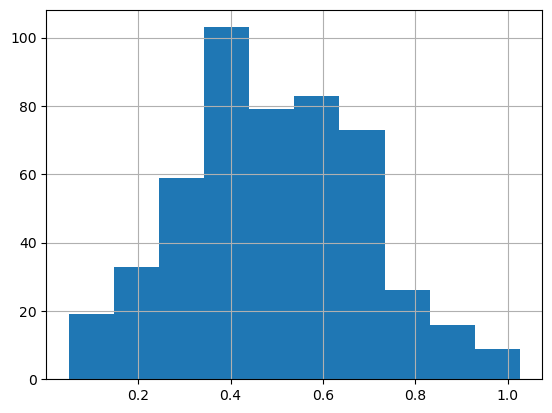

In [13]:
print(df['Credit_Utilization'].hist())
print(df['Missed_Payments'].value_counts())

#### Key Takeaways: Distribution Check

Missed Payments (Uniform Strains): The distribution of Missed_Payments is surprisingly uniform across the portfolio rather than right-skewed. The counts per bucket (e.g., 83 accounts with 4 missed payments vs. 77 accounts with 0 missed payments) reveal that structural, multi-month repayment failure is widespread across this dataset, rather than being isolated to a few extreme outliers.

Credit Utilization (Right-Centered Bell): The histogram indicates a dense concentration of accounts sitting between 40% and 70% utilization. The distribution trails off past 80% but stretches to a maximum of 102.6%, proving a subset of the portfolio is completely maxed out and operating over-limit.